<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/offshore_facility_concept_selection_with_neqsim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Offshore facility concept selection with NeqSim

This standalone decision lab compares nine development concepts for one synthetic offshore oil and
gas discovery:

* subsea tie-back to an existing host;
* subsea-to-shore;
* a normally unattended wellhead platform (NUI);
* a fixed steel jacket;
* a concrete gravity-based structure (GBS);
* an FPSO;
* a semi-submersible production unit;
* a tension-leg platform (TLP); and
* a spar.

The calculation chain connects geography, water depth, metocean statistics, environmental loads,
weather operability, NeqSim multiphase hydraulics and process simulation, topsides weight, technical
gates, lifecycle economics, weighted MCDA, TOPSIS, sensitivity analysis, and Monte Carlo robustness.

**Learning outcomes**

1. Turn a field-design basis into traceable concept-screening calculations.
2. Use extreme-value statistics and first-principles load equations at screening level.
3. Let NeqSim phase behavior, tie-back pressure loss, and process power influence facility choice.
4. Separate hard feasibility gates from preference-based ranking.
5. Quantify when a base-case recommendation changes under uncertainty.

All field, host, cost, schedule, and metocean values are synthetic educational assumptions. The
results are not a substitute for site-specific metocean studies, certified structural analysis,
flow-assurance design, concept select assurance, or investment approval.

In [1]:
import importlib.util
import subprocess
import sys
from importlib.metadata import version

requirements = {
    "neqsim": "neqsim==3.16.0",
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.8",
    "scipy": "scipy>=1.11",
}
missing = [
    package_spec
    for module_name, package_spec in requirements.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing]
    )

tested_versions = {
    package_name: version(package_name)
    for package_name in requirements
}
print("Runtime packages:")
for package_name, package_version in tested_versions.items():
    print(f"  {package_name}: {package_version}")

Runtime packages:
  neqsim: 3.16.0
  numpy: 2.5.1
  pandas: 3.0.3
  matplotlib: 3.11.1
  scipy: 1.17.0


## Decision workflow and system boundary

The notebook deliberately keeps two different decision layers:

1. **Hard gates** remove concepts that violate depth, route, host-ullage, topsides, or minimum
   operability limits.
2. **Preference methods** rank only the survivors using economics, emissions, availability, risk,
   and strategic fit.

This avoids the common mistake of allowing a very attractive NPV to compensate for a physically
infeasible concept. The boundary covers wells and SURF, receiving or standalone processing,
hydrocarbon export, offshore power, and facility-specific marine systems. Reservoir simulation,
detailed well design, geotechnics, structural dynamics, marine operations, and fiscal tax are
outside the screening boundary.

In [2]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import brentq
from scipy.stats import genextreme, spearmanr

warnings.filterwarnings("error", category=RuntimeWarning)
RANDOM_SEED = 7129
rng = np.random.default_rng(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5.5),
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

G_M_S2 = 9.80665
RHO_AIR_KG_M3 = 1.225
RHO_SEAWATER_KG_M3 = 1025.0
DISCOUNT_RATE = 0.08

## Synthetic field design basis

One editable input block controls the complete study. Pressure is absolute and all internal
calculations use SI units. Production is reported in standard volumes or barrels of oil equivalent
where explicitly labelled. The screening case represents a moderate North Sea discovery with a
nearby host and a longer route to shore.

The shortest geographic route uses the great-circle distance

$$
d = 2 R \arcsin\left(
\sqrt{
\sin^2\left(\frac{\Delta\phi}{2}\right)
+ \cos\phi_1 \cos\phi_2
\sin^2\left(\frac{\Delta\lambda}{2}\right)
}
\right),
$$

where $\phi$ is latitude, $\lambda$ is longitude, and $R = 6371\ \mathrm{km}$.

In [3]:
field = {
    "name": "North Sea Alpha (synthetic)",
    "latitude_deg": 65.70,
    "longitude_deg": 4.20,
    "water_depth_m": 320.0,
    "recoverable_mmboe": 65.0,
    "plateau_mboe_day": 24.0,
    "design_life_years": 17,
    "wellstream_kg_h": 120_000.0,
    "wellhead_pressure_bara": 220.0,
    "wellhead_temperature_c": 60.0,
    "host_ullage_mboe_day": 36.0,
}

infrastructure = pd.DataFrame(
    [
        {
            "name": "Host Alpha",
            "kind": "existing host",
            "latitude_deg": 65.96,
            "longitude_deg": 4.63,
            "processing_ullage_mboe_day": 36.0,
        },
        {
            "name": "Host Beta",
            "kind": "existing host",
            "latitude_deg": 65.42,
            "longitude_deg": 3.34,
            "processing_ullage_mboe_day": 18.0,
        },
        {
            "name": "Coastal terminal",
            "kind": "shore terminal",
            "latitude_deg": 64.45,
            "longitude_deg": 8.35,
            "processing_ullage_mboe_day": np.nan,
        },
    ]
)

field_table = pd.Series(field, name="Value").to_frame()
display(field_table)

,Value
name,North Sea Alpha (synthetic)
latitude_deg,65.7
longitude_deg,4.2
water_depth_m,320.0
recoverable_mmboe,65.0
plateau_mboe_day,24.0
design_life_years,17
wellstream_kg_h,120000.0
wellhead_pressure_bara,220.0
wellhead_temperature_c,60.0


### Route and infrastructure calculation

Great-circle distance is adequate for early screening. A real route would add bathymetry,
exclusion zones, seabed slope, crossings, landfall constraints, and routing contingency. The map
below is a coordinate view rather than a navigational chart.

,name,kind,distance_km,processing_ullage_mboe_day
0,Host Alpha,existing host,34.9,36.0
1,Host Beta,existing host,50.3,18.0
2,Coastal terminal,shore terminal,239.0,NaN


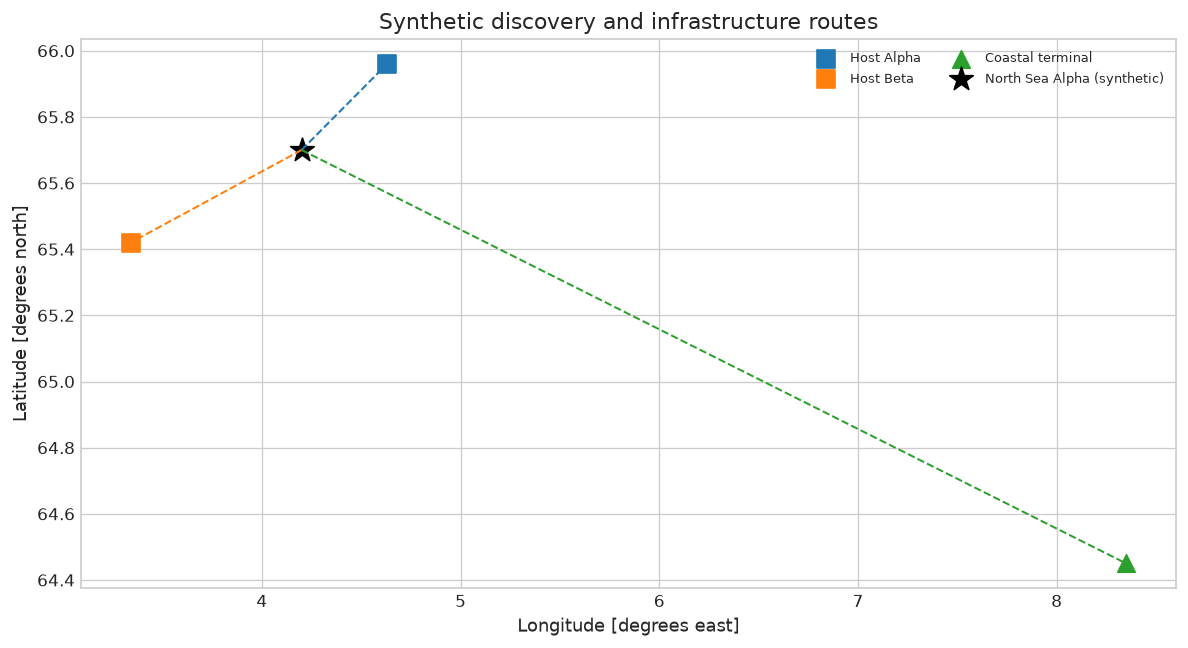

In [4]:
def haversine_distance_km(latitude_1, longitude_1, latitude_2, longitude_2):
    radius_km = 6371.0
    lat_1 = np.radians(latitude_1)
    lat_2 = np.radians(latitude_2)
    delta_lat = np.radians(latitude_2 - latitude_1)
    delta_lon = np.radians(longitude_2 - longitude_1)
    haversine_value = (
        np.sin(delta_lat / 2.0) ** 2
        + np.cos(lat_1) * np.cos(lat_2) * np.sin(delta_lon / 2.0) ** 2
    )
    return 2.0 * radius_km * np.arcsin(np.sqrt(haversine_value))


infrastructure["distance_km"] = haversine_distance_km(
    field["latitude_deg"],
    field["longitude_deg"],
    infrastructure["latitude_deg"].to_numpy(),
    infrastructure["longitude_deg"].to_numpy(),
)
nearest_host = infrastructure.loc[
    infrastructure["kind"].eq("existing host")
].sort_values("distance_km").iloc[0]
shore_terminal = infrastructure.loc[
    infrastructure["kind"].eq("shore terminal")
].iloc[0]

display(
    infrastructure[
        ["name", "kind", "distance_km", "processing_ullage_mboe_day"]
    ].round(1)
)

fig, ax = plt.subplots()
for _, asset in infrastructure.iterrows():
    marker = "s" if asset["kind"] == "existing host" else "^"
    ax.scatter(
        asset["longitude_deg"],
        asset["latitude_deg"],
        marker=marker,
        s=110,
        label=asset["name"],
    )
    ax.plot(
        [field["longitude_deg"], asset["longitude_deg"]],
        [field["latitude_deg"], asset["latitude_deg"]],
        linestyle="--",
        linewidth=1.2,
    )
ax.scatter(
    field["longitude_deg"],
    field["latitude_deg"],
    marker="*",
    s=220,
    color="black",
    label=field["name"],
)
ax.set_xlabel("Longitude [degrees east]")
ax.set_ylabel("Latitude [degrees north]")
ax.set_title("Synthetic discovery and infrastructure routes")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Synthetic metocean record and weather extremes

The synthetic daily series is deliberately seasonal and storm-driven. It is used to demonstrate the
method; it is not a substitute for hindcast, buoy, satellite, or joint-probability data.

Annual maxima are fitted with the generalized extreme-value distribution

$$
G(z) =
\exp\left[
-\left(
1 + \xi \frac{z-\mu}{\sigma}
\right)^{-1/\xi}
\right],
$$

for $1 + \xi(z-\mu)/\sigma > 0$. A return level $z_T$ satisfies

$$
G(z_T) = 1 - \frac{1}{T},
$$

where $T$ is the return period in years. Operational availability is calculated directly from the
daily distribution rather than from the extreme value.

,Hs_m,Tp_s,wind_m_s,current_m_s
count,5479.00,5479.00,5479.00,5479.00
mean,1.45,6.20,8.30,0.47
std,0.99,1.06,3.17,0.12
min,0.15,4.00,0.50,0.05
50%,1.26,6.11,8.02,0.47
90%,2.71,7.53,12.35,0.62
99%,4.52,9.20,17.06,0.75
max,11.97,15.13,35.97,0.91


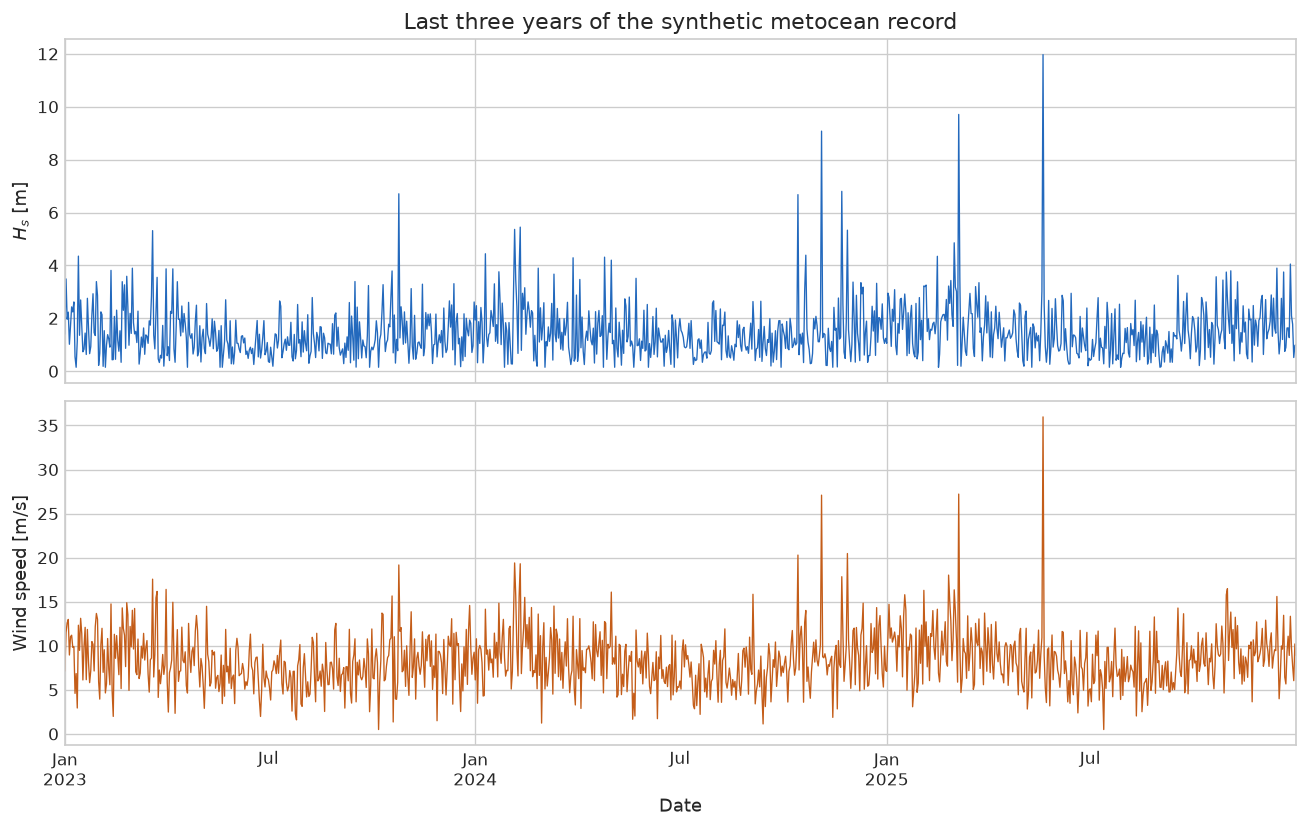

In [5]:
metocean_dates = pd.date_range("2011-01-01", "2025-12-31", freq="D")
day_of_year = metocean_dates.dayofyear.to_numpy()
winter_factor = 1.0 + 0.30 * np.cos(2.0 * np.pi * (day_of_year - 20) / 365.25)

base_wave = rng.weibull(1.75, len(metocean_dates)) * 1.55 * winter_factor
storm_mask = rng.random(len(metocean_dates)) < 0.018
storm_increment = storm_mask * rng.gamma(2.4, 1.15, len(metocean_dates))
significant_wave_height_m = np.clip(base_wave + storm_increment, 0.15, None)
peak_period_s = np.clip(
    5.0
    + 0.82 * significant_wave_height_m
    + rng.normal(0.0, 0.7, len(metocean_dates)),
    4.0,
    18.0,
)
wind_speed_m_s = np.clip(
    5.0
    + 2.3 * significant_wave_height_m
    + 2.0 * (winter_factor - 1.0)
    + rng.normal(0.0, 2.0, len(metocean_dates)),
    0.5,
    None,
)
current_speed_m_s = np.clip(
    0.42
    + 0.035 * significant_wave_height_m
    + rng.normal(0.0, 0.11, len(metocean_dates)),
    0.05,
    1.35,
)

metocean = pd.DataFrame(
    {
        "Hs_m": significant_wave_height_m,
        "Tp_s": peak_period_s,
        "wind_m_s": wind_speed_m_s,
        "current_m_s": current_speed_m_s,
    },
    index=metocean_dates,
)
display(metocean.describe(percentiles=[0.5, 0.9, 0.99]).round(2))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
metocean.loc["2023":"2025", "Hs_m"].plot(
    ax=axes[0],
    color="#2369bd",
    linewidth=0.8,
)
axes[0].set_ylabel("$H_s$ [m]")
axes[0].set_title("Last three years of the synthetic metocean record")
metocean.loc["2023":"2025", "wind_m_s"].plot(
    ax=axes[1],
    color="#c45d19",
    linewidth=0.8,
)
axes[1].set_ylabel("Wind speed [m/s]")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

### Extreme-value fit

Fifteen annual maxima are only enough for a teaching demonstration. Project work should examine
data homogeneity, storm independence, directional sectors, threshold models, parameter uncertainty,
joint wave-wind-current conditions, and climate non-stationarity. The fitted values are therefore
screening inputs, not characteristic design values.

,Return period [year],Significant wave height [m],Wind speed [m/s]
0,2.0,7.24,21.48
1,10.0,9.87,30.16
2,50.0,11.84,48.23
3,100.0,12.60,61.57


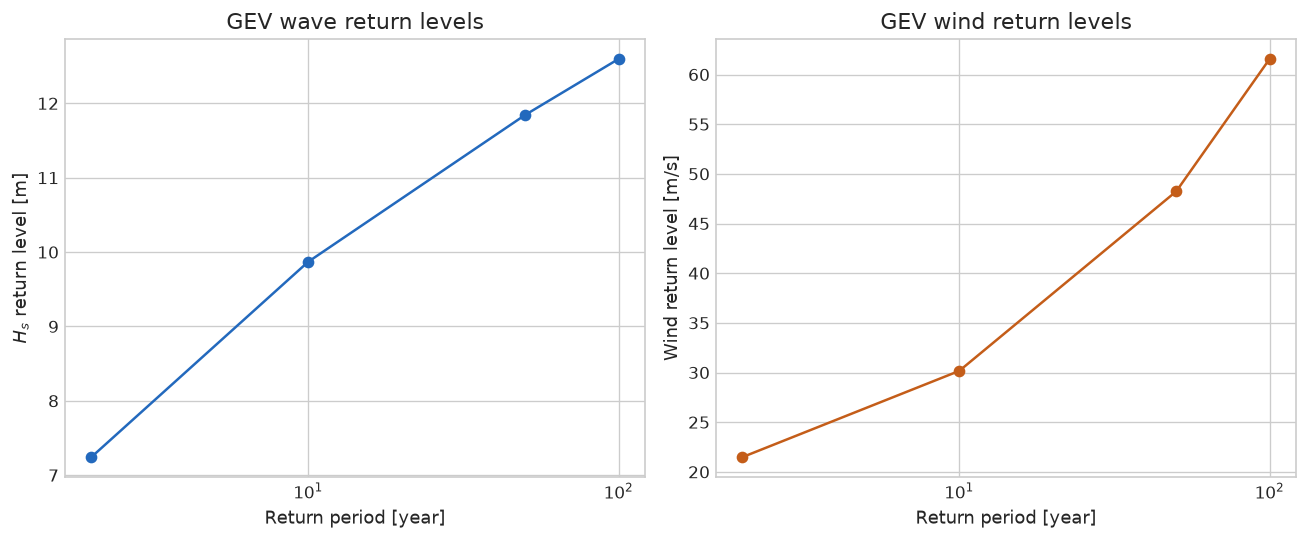

In [6]:
def fit_gev_return_levels(series, return_periods):
    annual_maxima = series.groupby(series.index.year).max().to_numpy()
    shape, location, scale = genextreme.fit(annual_maxima)
    non_exceedance = 1.0 - 1.0 / np.asarray(return_periods, dtype=float)
    return_levels = genextreme.ppf(
        non_exceedance,
        shape,
        loc=location,
        scale=scale,
    )
    return {
        "shape": shape,
        "location": location,
        "scale": scale,
        "annual_maxima": annual_maxima,
        "return_levels": return_levels,
    }


return_periods_year = np.array([2.0, 10.0, 50.0, 100.0])
wave_gev = fit_gev_return_levels(metocean["Hs_m"], return_periods_year)
wind_gev = fit_gev_return_levels(metocean["wind_m_s"], return_periods_year)

return_level_table = pd.DataFrame(
    {
        "Return period [year]": return_periods_year,
        "Significant wave height [m]": wave_gev["return_levels"],
        "Wind speed [m/s]": wind_gev["return_levels"],
    }
)
display(return_level_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].plot(
    return_periods_year,
    wave_gev["return_levels"],
    marker="o",
    color="#2369bd",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Return period [year]")
axes[0].set_ylabel("$H_s$ return level [m]")
axes[0].set_title("GEV wave return levels")
axes[1].plot(
    return_periods_year,
    wind_gev["return_levels"],
    marker="o",
    color="#c45d19",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Return period [year]")
axes[1].set_ylabel("Wind return level [m/s]")
axes[1].set_title("GEV wind return levels")
plt.tight_layout()
plt.show()

## Screening environmental loads

Wind and current drag use

$$
F_D = \frac{1}{2}\rho C_D A U^2.
$$

Linear-wave kinematics use the dispersion relation

$$
\omega^2 = g k \tanh(kh).
$$

Morison loading is used only for explicitly slender cylindrical members:

$$
\frac{\mathrm{d}F}{\mathrm{d}z}
=
\frac{1}{2}\rho C_D D u|u|
+
\rho C_M \frac{\pi D^2}{4}\dot{u}.
$$

Large-volume floaters and gravity structures are outside the strict Morison regime. For them, the
notebook uses a labelled wave-drift screening term. Diffraction/radiation analysis, response
amplitude operators, second-order motion, air gap, green water, slamming, vortex-induced motion,
fatigue, soil-foundation response, and coupled mooring-riser dynamics remain project work.

In [7]:
def wave_number_rad_m(period_s, water_depth_m):
    angular_frequency = 2.0 * np.pi / period_s

    def dispersion_residual(wave_number):
        return (
            G_M_S2
            * wave_number
            * np.tanh(wave_number * water_depth_m)
            - angular_frequency**2
        )

    return brentq(dispersion_residual, 1.0e-6, 10.0)


def airy_surface_kinematics(wave_height_m, period_s, water_depth_m):
    wave_number = wave_number_rad_m(period_s, water_depth_m)
    angular_frequency = 2.0 * np.pi / period_s
    amplitude_m = wave_height_m / 2.0
    velocity_amplitude = (
        amplitude_m
        * angular_frequency
        / np.tanh(wave_number * water_depth_m)
    )
    acceleration_amplitude = angular_frequency * velocity_amplitude
    return wave_number, velocity_amplitude, acceleration_amplitude


def drag_force_mn(density_kg_m3, drag_coefficient, area_m2, velocity_m_s):
    force_n = (
        0.5
        * density_kg_m3
        * drag_coefficient
        * area_m2
        * velocity_m_s**2
    )
    return force_n / 1.0e6


def morison_slender_force_mn(
    diameter_m,
    total_member_length_m,
    velocity_m_s,
    acceleration_m_s2,
    drag_coefficient=1.0,
    inertia_coefficient=2.0,
):
    drag_per_length = (
        0.5
        * RHO_SEAWATER_KG_M3
        * drag_coefficient
        * diameter_m
        * velocity_m_s
        * abs(velocity_m_s)
    )
    inertia_per_length = (
        RHO_SEAWATER_KG_M3
        * inertia_coefficient
        * np.pi
        * diameter_m**2
        * acceleration_m_s2
        / 4.0
    )
    return (drag_per_length + inertia_per_length) * total_member_length_m / 1.0e6


def wave_drift_screening_mn(
    significant_wave_height_m,
    waterplane_beam_m,
    coefficient,
):
    force_n = (
        coefficient
        * RHO_SEAWATER_KG_M3
        * G_M_S2
        * significant_wave_height_m**2
        * waterplane_beam_m
        / 16.0
    )
    return force_n / 1.0e6

,Wind [MN],Current [MN],Wave screening [MN],Total screening [MN]
Concept,,,,
Subsea tie-back,0.00,0.00,0.00,0.00
Subsea-to-shore,0.00,0.00,0.00,0.00
NUI wellhead platform,1.54,0.25,1.56,3.34
Fixed jacket,3.76,0.63,7.00,11.39
Concrete gravity base,5.13,2.28,6.79,14.19
FPSO,7.69,1.09,7.16,15.94
Semi-submersible,5.64,0.74,7.93,14.31
TLP,4.79,0.60,4.85,10.23
Spar,3.25,0.46,2.68,6.38


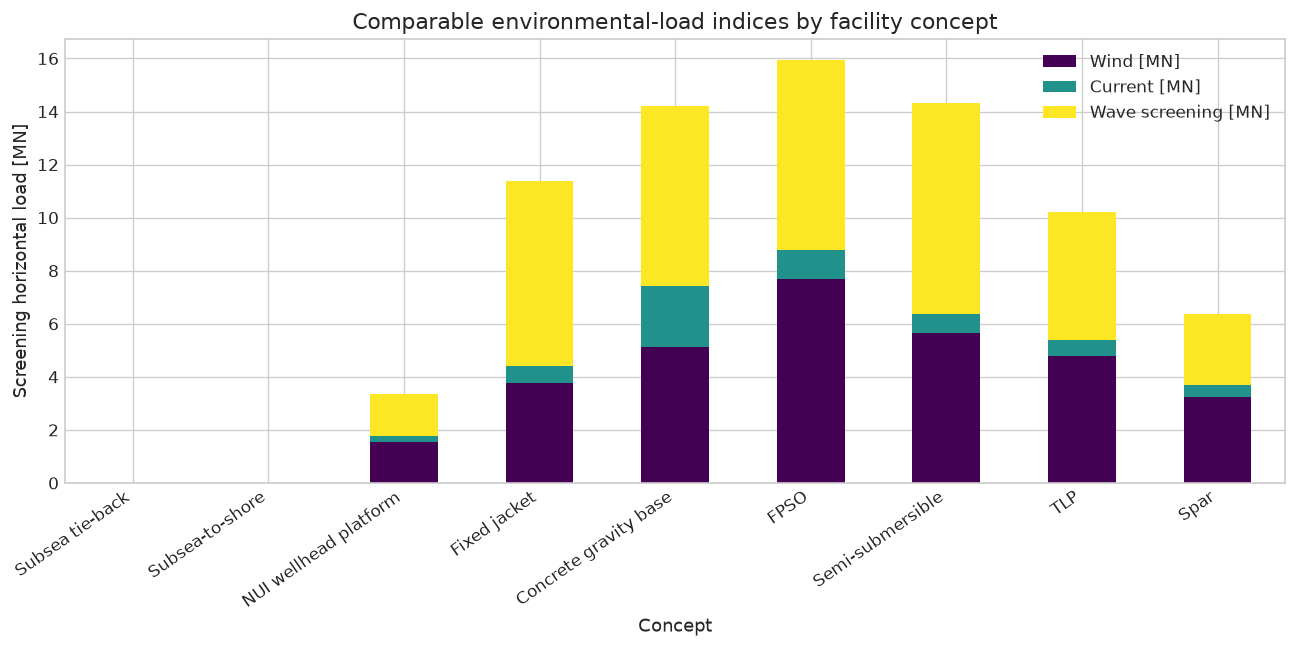

In [8]:
wave_50_m = float(wave_gev["return_levels"][2])
wind_50_m_s = float(wind_gev["return_levels"][2])
current_50_m_s = float(metocean["current_m_s"].quantile(0.999))
period_50_s = float(np.clip(6.0 + 0.78 * wave_50_m, 10.0, 18.0))
wave_number_50, orbital_velocity_50, orbital_acceleration_50 = (
    airy_surface_kinematics(
        wave_50_m,
        period_50_s,
        field["water_depth_m"],
    )
)

load_inputs = pd.DataFrame(
    [
        ("Subsea tie-back", "subsea", 0.0, 0.0, False, 0.0, 0.0),
        ("Subsea-to-shore", "subsea", 0.0, 0.0, False, 0.0, 0.0),
        ("NUI wellhead platform", "slender", 900.0, 700.0, True, 1.2, 260.0),
        ("Fixed jacket", "slender", 2200.0, 1800.0, True, 1.5, 850.0),
        ("Concrete gravity base", "large-volume", 3000.0, 6500.0, False, 70.0, 1.1),
        ("FPSO", "large-volume", 4500.0, 3100.0, False, 58.0, 1.4),
        ("Semi-submersible", "large-volume", 3300.0, 2100.0, False, 75.0, 1.2),
        ("TLP", "large-volume", 2800.0, 1700.0, False, 55.0, 1.0),
        ("Spar", "large-volume", 1900.0, 1300.0, False, 38.0, 0.8),
    ],
    columns=[
        "concept",
        "load_model",
        "wind_area_m2",
        "current_area_m2",
        "use_morison",
        "member_diameter_or_beam_m",
        "member_length_or_drift_coefficient",
    ],
).set_index("concept")

load_rows = []
for concept_name, values in load_inputs.iterrows():
    wind_force_mn = drag_force_mn(
        RHO_AIR_KG_M3,
        1.2,
        values["wind_area_m2"],
        wind_50_m_s,
    )
    current_force_mn = drag_force_mn(
        RHO_SEAWATER_KG_M3,
        1.0,
        values["current_area_m2"],
        current_50_m_s,
    )
    if values["use_morison"]:
        wave_force_mn = morison_slender_force_mn(
            values["member_diameter_or_beam_m"],
            values["member_length_or_drift_coefficient"],
            orbital_velocity_50,
            orbital_acceleration_50,
        )
    elif values["load_model"] == "large-volume":
        wave_force_mn = wave_drift_screening_mn(
            wave_50_m,
            values["member_diameter_or_beam_m"],
            values["member_length_or_drift_coefficient"],
        )
    else:
        wave_force_mn = 0.0
    load_rows.append(
        {
            "Concept": concept_name,
            "Wind [MN]": wind_force_mn,
            "Current [MN]": current_force_mn,
            "Wave screening [MN]": wave_force_mn,
            "Total screening [MN]": (
                wind_force_mn + current_force_mn + wave_force_mn
            ),
        }
    )

load_results = pd.DataFrame(load_rows).set_index("Concept")
display(load_results.round(2))

load_results[
    ["Wind [MN]", "Current [MN]", "Wave screening [MN]"]
].plot(kind="bar", stacked=True, figsize=(11, 5.5), colormap="viridis")
plt.ylabel("Screening horizontal load [MN]")
plt.title("Comparable environmental-load indices by facility concept")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

The load chart is useful for relative screening and for exposing which term drives each concept. It
must not be interpreted as a code-compliant base shear, mooring line tension, tendon tension, or
global response. The zero shown for subsea-only concepts means no surface facility is included in
this boundary; subsea equipment and pipeline stability still require hydrodynamic design.

## Facility concept catalogue

The catalogue is data rather than branching code. Each row contains the depth envelope, route
limit, host dependency, operational wave limit, topsides capacity, cost scaling, schedule, and
risk attributes used by subsequent functions. These values are transparent screening assumptions
chosen to make the notebook reusable.

In [9]:
concepts = pd.DataFrame(
    [
        (
            "Subsea tie-back", "subsea", 20, 2500, 60, "host", 4.0, 900,
            520, 0.8, 0.040, 30, 0.25, 0.25, 0.18, 0.95, 0.45,
        ),
        (
            "Subsea-to-shore", "subsea", 20, 3000, 180, "shore", 4.0, 800,
            680, 0.9, 0.035, 48, 0.45, 0.50, 0.20, 0.70, 0.55,
        ),
        (
            "NUI wellhead platform", "fixed", 20, 350, 90, "host", 3.0,
            1800, 1050, 5.0, 0.045, 42, 0.32, 0.38, 0.25, 0.82, 0.70,
        ),
        (
            "Fixed jacket", "fixed", 20, 380, 200, "export", 3.5, 7000,
            1650, 4.0, 0.050, 54, 0.30, 0.42, 0.32, 0.72, 1.00,
        ),
        (
            "Concrete gravity base", "fixed", 20, 260, 200, "export", 3.5,
            9000, 2900, 3.0, 0.045, 66, 0.42, 0.58, 0.30, 0.55, 1.05,
        ),
        (
            "FPSO", "floating", 50, 3000, 500, "tanker", 4.5, 8500,
            2450, 1.2, 0.055, 48, 0.35, 0.38, 0.38, 0.78, 1.10,
        ),
        (
            "Semi-submersible", "floating", 50, 3000, 500, "export", 5.0,
            8000, 2750, 1.5, 0.055, 54, 0.38, 0.45, 0.36, 0.70, 1.05,
        ),
        (
            "TLP", "floating", 180, 1800, 500, "export", 4.5, 7800,
            3150, 1.8, 0.050, 60, 0.48, 0.55, 0.34, 0.64, 1.00,
        ),
        (
            "Spar", "floating", 300, 3000, 500, "export", 4.8, 7200,
            3450, 1.4, 0.050, 63, 0.48, 0.58, 0.32, 0.60, 0.95,
        ),
    ],
    columns=[
        "concept",
        "category",
        "min_depth_m",
        "max_depth_m",
        "max_route_km",
        "export_mode",
        "operating_hs_limit_m",
        "topside_limit_t",
        "base_capex_musd",
        "depth_capex_musd_m",
        "opex_fraction",
        "schedule_months",
        "technical_risk",
        "execution_risk",
        "hse_risk",
        "strategic_fit",
        "process_weight_factor",
    ],
).set_index("concept")

display(
    concepts[
        [
            "category",
            "min_depth_m",
            "max_depth_m",
            "max_route_km",
            "operating_hs_limit_m",
            "schedule_months",
        ]
    ]
)

,category,min_depth_m,max_depth_m,max_route_km,operating_hs_limit_m,schedule_months
concept,,,,,,
Subsea tie-back,subsea,20,2500,60,4.0,30
Subsea-to-shore,subsea,20,3000,180,4.0,48
NUI wellhead platform,fixed,20,350,90,3.0,42
Fixed jacket,fixed,20,380,200,3.5,54
Concrete gravity base,fixed,20,260,200,3.5,66
FPSO,floating,50,3000,500,4.5,48
Semi-submersible,floating,50,3000,500,5.0,54
TLP,floating,180,1800,500,4.5,60
Spar,floating,300,3000,500,4.8,63


## Weather operability

Weather availability is the fraction of daily sea states below each concept's operational
significant-wave-height threshold:

$$
A_i = \frac{1}{N}\sum_{t=1}^{N}
\mathbb{1}\left(H_{s,t} \leq H_{s,\mathrm{lim},i}\right).
$$

It represents a simple marine-access or offloading screen. Real operations use persistence,
forecast uncertainty, simultaneous wind and wave limits, approach direction, vessel capability,
and campaign duration.

,Availability mean [-],Availability minimum year [-],Weather downtime [day/year]
Subsea tie-back,0.982,0.970,6.732
Subsea-to-shore,0.982,0.970,6.732
NUI wellhead platform,0.930,0.907,25.464
Fixed jacket,0.966,0.954,12.531
Concrete gravity base,0.966,0.954,12.531
FPSO,0.990,0.981,3.733
Semi-submersible,0.994,0.984,2.333
TLP,0.990,0.981,3.733
Spar,0.993,0.984,2.666


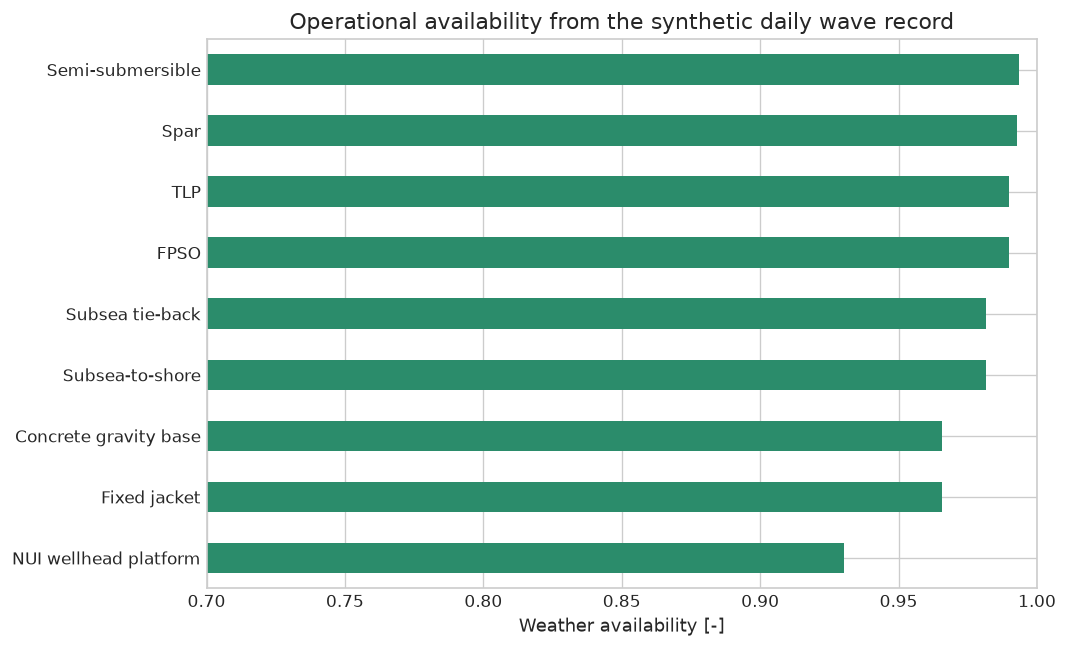

In [10]:
operability = {}
for concept_name, values in concepts.iterrows():
    wave_limit_m = values["operating_hs_limit_m"]
    annual_availability = (
        metocean["Hs_m"].le(wave_limit_m).groupby(metocean.index.year).mean()
    )
    operability[concept_name] = {
        "Availability mean [-]": annual_availability.mean(),
        "Availability minimum year [-]": annual_availability.min(),
        "Weather downtime [day/year]": 365.25 * (1.0 - annual_availability.mean()),
    }

operability_results = pd.DataFrame(operability).T
display(operability_results.round(3))

operability_results["Availability mean [-]"].sort_values().plot(
    kind="barh",
    color="#2b8c6b",
    figsize=(9, 5.5),
)
plt.xlabel("Weather availability [-]")
plt.ylabel("")
plt.xlim(0.70, 1.0)
plt.title("Operational availability from the synthetic daily wave record")
plt.tight_layout()
plt.show()

## NeqSim connection: wellstream, tie-back, separation, and gas export

NeqSim 3.16.0 provides the thermodynamic and process basis. The wellstream uses SRK with the classic
mixing rule and multiphase checking. A native `PipeBeggsAndBrills` model calculates the pressure
loss from the discovery to the nearest host. A composable process model then performs inlet
throttling, phase separation, gas compression to 180 bara, and aftercooling.

The two models use the same composition and mass rate but different boundary pressures:

* tie-back inlet: $220\ \mathrm{bara}$ and $60^\circ\mathrm{C}$;
* process inlet: $70\ \mathrm{bara}$ and $60^\circ\mathrm{C}$.

This is a concept screen. Detailed work should use a characterized reservoir fluid, terrain profile,
heat transfer, hydrate and wax constraints, slugging, receiving-facility limits, compressor maps,
water treatment, oil stabilization, and recycle convergence.

In [11]:
from neqsim import jneqsim

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

WELLSTREAM_COMPOSITION = {
    "nitrogen": 0.005,
    "CO2": 0.010,
    "methane": 0.550,
    "ethane": 0.090,
    "propane": 0.075,
    "n-butane": 0.060,
    "n-pentane": 0.050,
    "n-hexane": 0.045,
    "n-heptane": 0.040,
    "n-octane": 0.035,
    "n-nonane": 0.025,
    "nC10": 0.015,
}
assert math.isclose(sum(WELLSTREAM_COMPOSITION.values()), 1.0, abs_tol=1.0e-12)


def create_wellstream(temperature_c, pressure_bara, flow_kg_h):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)
    for component_name, mole_fraction in WELLSTREAM_COMPOSITION.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    return fluid

In [12]:
tieback_fluid = create_wellstream(
    field["wellhead_temperature_c"],
    field["wellhead_pressure_bara"],
    field["wellstream_kg_h"],
)
tieback_inlet = Stream("tie-back inlet", tieback_fluid)
tieback_inlet.run()
tieback_pipe = PipeBeggsAndBrills("38 km production flowline", tieback_inlet)
tieback_pipe.setLength(float(nearest_host["distance_km"]) * 1000.0)
tieback_pipe.setElevation(field["water_depth_m"])
tieback_pipe.setDiameter(0.3048)
tieback_pipe.setPipeWallRoughness(5.0e-5)
tieback_pipe.setNumberOfIncrements(40)
tieback_pipe.run()

process_fluid = create_wellstream(
    field["wellhead_temperature_c"],
    70.0,
    field["wellstream_kg_h"],
)
process_feed = Stream("facility feed", process_fluid)
inlet_valve = ThrottlingValve("inlet pressure control", process_feed)
inlet_valve.setOutletPressure(30.0, "bara")
inlet_separator = Separator("inlet separator", inlet_valve.getOutletStream())
export_compressor = Compressor(
    "gas export compressor",
    inlet_separator.getGasOutStream(),
)
export_compressor.setOutletPressure(180.0, "bara")
export_compressor.setIsentropicEfficiency(0.78)
export_aftercooler = Cooler(
    "gas export aftercooler",
    export_compressor.getOutletStream(),
)
export_aftercooler.setOutTemperature(40.0 + 273.15)

facility_process = ProcessSystem()
for process_unit in [
    process_feed,
    inlet_valve,
    inlet_separator,
    export_compressor,
    export_aftercooler,
]:
    facility_process.add(process_unit)
facility_process.run()

neqsim_summary = pd.Series(
    {
        "Tie-back inlet pressure [bara]": field["wellhead_pressure_bara"],
        "Tie-back outlet pressure [bara]": tieback_pipe.getOutletPressure(),
        "Tie-back pressure drop [bar]": tieback_pipe.getPressureDrop(),
        "Separator pressure [bara]": inlet_separator.getPressure(),
        "Gas compressor power [MW]": export_compressor.getPower("MW"),
        "Aftercooler duty magnitude [MW]": abs(export_aftercooler.getDuty()) / 1.0e6,
    },
    name="NeqSim result",
)
display(neqsim_summary.round(3).to_frame())

,NeqSim result
Tie-back inlet pressure [bara],220.000
Tie-back outlet pressure [bara],202.636
Tie-back pressure drop [bar],17.364
Separator pressure [bara],30.000
Gas compressor power [MW],3.896
Aftercooler duty magnitude [MW],6.338


In [13]:
process_streams = {
    "Facility feed": process_feed,
    "Valve outlet": inlet_valve.getOutletStream(),
    "Separator gas": inlet_separator.getGasOutStream(),
    "Separator liquid": inlet_separator.getLiquidOutStream(),
    "Compressor outlet": export_compressor.getOutletStream(),
    "Aftercooler outlet": export_aftercooler.getOutletStream(),
}
stream_rows = []
for stream_name, process_stream in process_streams.items():
    stream_fluid = process_stream.getFluid()
    stream_rows.append(
        {
            "Stream": stream_name,
            "Flow [kg/h]": process_stream.getFlowRate("kg/hr"),
            "Temperature [°C]": process_stream.getTemperature("C"),
            "Pressure [bara]": process_stream.getPressure("bara"),
            "Phases [-]": stream_fluid.getNumberOfPhases(),
        }
    )

stream_results = pd.DataFrame(stream_rows).set_index("Stream")
separator_mass_residual_kg_h = (
    process_feed.getFlowRate("kg/hr")
    - inlet_separator.getGasOutStream().getFlowRate("kg/hr")
    - inlet_separator.getLiquidOutStream().getFlowRate("kg/hr")
)
display(stream_results.round(3))
print(f"Separator mass residual: {separator_mass_residual_kg_h:.3e} kg/h")

Separator mass residual: -1.455e-11 kg/h


,Flow [kg/h],Temperature [°C],Pressure [bara],Phases [-]
Stream,,,,
Facility feed,120000.000,60.000,70.0,2
Valve outlet,120000.000,48.903,30.0,2
Separator gas,45431.975,48.903,30.0,1
Separator liquid,74568.025,48.903,30.0,1
Compressor outlet,45431.975,201.512,180.0,1
Aftercooler outlet,45431.975,40.000,180.0,1


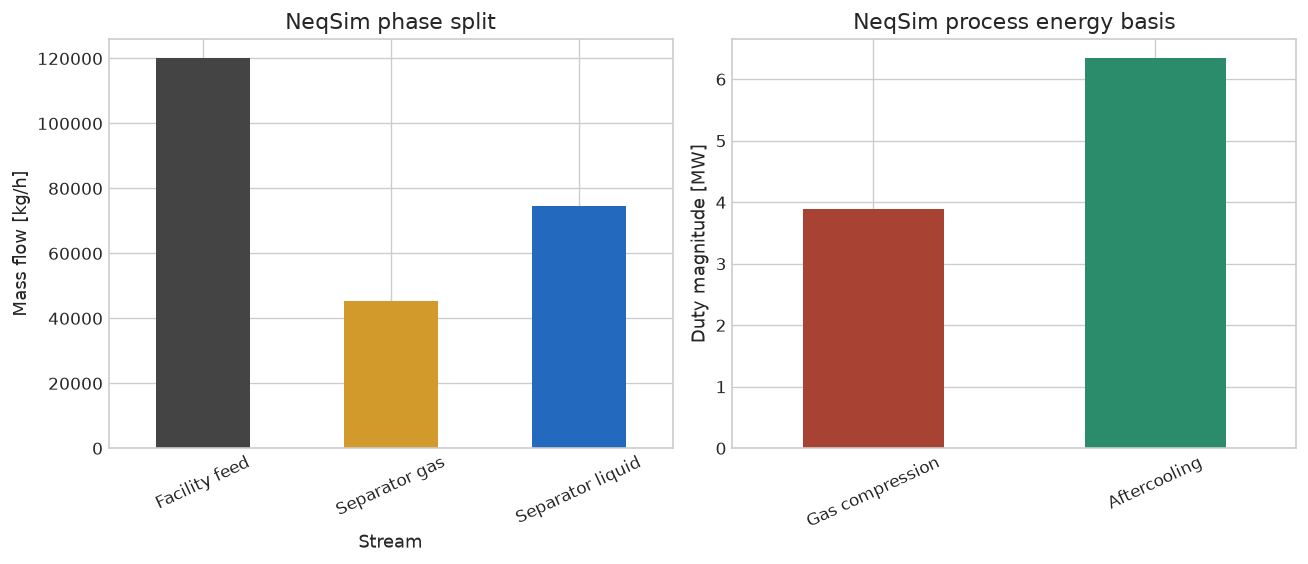

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
stream_results.loc[
    ["Facility feed", "Separator gas", "Separator liquid"],
    "Flow [kg/h]",
].plot(kind="bar", ax=axes[0], color=["#444444", "#d19a2a", "#2369bd"])
axes[0].set_ylabel("Mass flow [kg/h]")
axes[0].set_title("NeqSim phase split")
axes[0].tick_params(axis="x", rotation=25)

energy_values = pd.Series(
    {
        "Gas compression": export_compressor.getPower("MW"),
        "Aftercooling": abs(export_aftercooler.getDuty()) / 1.0e6,
    }
)
energy_values.plot(kind="bar", ax=axes[1], color=["#a84232", "#2b8c6b"])
axes[1].set_ylabel("Duty magnitude [MW]")
axes[1].set_title("NeqSim process energy basis")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## Process-to-facility scaling

The NeqSim process result is converted into a transparent screening topsides weight. It combines a
fixed utilities-and-structure allowance, a power-related term, and a throughput-related term:

$$
W_{\mathrm{top}}
=
W_0
+ a_P P_{\mathrm{comp}}
+ a_m \dot{m}.
$$

Concept factors then represent how much processing remains at the field location. A tie-back moves
most processing to the host, while a standalone floater or fixed platform carries the complete
train. This correlation is only for concept differentiation; equipment-level mechanical design and
discipline weight reports are needed in later phases.

In [15]:
compressor_power_mw = export_compressor.getPower("MW")
throughput_t_day = field["wellstream_kg_h"] * 24.0 / 1000.0
full_process_weight_t = (
    2400.0
    + 52.0 * compressor_power_mw
    + 0.075 * throughput_t_day
)
process_weight_factors = {
    "Subsea tie-back": 0.18,
    "Subsea-to-shore": 0.10,
    "NUI wellhead platform": 0.42,
    "Fixed jacket": 1.00,
    "Concrete gravity base": 1.05,
    "FPSO": 1.10,
    "Semi-submersible": 1.05,
    "TLP": 1.00,
    "Spar": 0.95,
}
concepts["estimated_topside_weight_t"] = pd.Series(
    {
        concept_name: full_process_weight_t * process_weight_factors[concept_name]
        for concept_name in concepts.index
    }
)
concepts["topside_utilization"] = (
    concepts["estimated_topside_weight_t"] / concepts["topside_limit_t"]
)

display(
    concepts[
        [
            "estimated_topside_weight_t",
            "topside_limit_t",
            "topside_utilization",
        ]
    ].round(3)
)

,estimated_topside_weight_t,topside_limit_t,topside_utilization
concept,,,
Subsea tie-back,507.351,900,0.564
Subsea-to-shore,281.861,800,0.352
NUI wellhead platform,1183.818,1800,0.658
Fixed jacket,2818.615,7000,0.403
Concrete gravity base,2959.546,9000,0.329
FPSO,3100.476,8500,0.365
Semi-submersible,2959.546,8000,0.370
TLP,2818.615,7800,0.361
Spar,2677.684,7200,0.372


## Hard technical gates

The gate vector for concept $i$ is

$$
\mathbf{g}_i =
\left[
g_{\mathrm{depth}},
g_{\mathrm{route}},
g_{\mathrm{host}},
g_{\mathrm{topside}},
g_{\mathrm{operability}},
g_{\mathrm{marine}}
\right],
$$

and technical feasibility requires $\prod_j g_{ij}=1$. Route gates use the nearest host for host
concepts and the coastal terminal for subsea-to-shore. Host ullage is checked against plateau
production. The marine-load gate is a deliberately broad screening capacity, not a structural
unity check.

In [16]:
marine_screening_capacity_mn = {
    "Subsea tie-back": np.inf,
    "Subsea-to-shore": np.inf,
    "NUI wellhead platform": 85.0,
    "Fixed jacket": 420.0,
    "Concrete gravity base": 900.0,
    "FPSO": 160.0,
    "Semi-submersible": 150.0,
    "TLP": 130.0,
    "Spar": 105.0,
}


def route_distance_for_concept(concept_name, export_mode):
    if concept_name == "Subsea-to-shore":
        return float(shore_terminal["distance_km"])
    if export_mode == "host":
        return float(nearest_host["distance_km"])
    return 0.0


gate_rows = []
for concept_name, values in concepts.iterrows():
    route_distance_km = route_distance_for_concept(
        concept_name,
        values["export_mode"],
    )
    host_required = values["export_mode"] == "host"
    gate_rows.append(
        {
            "Concept": concept_name,
            "Depth": (
                values["min_depth_m"]
                <= field["water_depth_m"]
                <= values["max_depth_m"]
            ),
            "Route": route_distance_km <= values["max_route_km"],
            "Host ullage": (
                not host_required
                or field["host_ullage_mboe_day"]
                >= field["plateau_mboe_day"]
            ),
            "Topside": values["topside_utilization"] <= 1.0,
            "Operability": (
                operability_results.loc[
                    concept_name,
                    "Availability mean [-]",
                ]
                >= 0.78
            ),
            "Marine load": (
                load_results.loc[
                    concept_name,
                    "Total screening [MN]",
                ]
                <= marine_screening_capacity_mn[concept_name]
            ),
            "Route distance [km]": route_distance_km,
        }
    )

gate_results = pd.DataFrame(gate_rows).set_index("Concept")
gate_columns = [
    "Depth",
    "Route",
    "Host ullage",
    "Topside",
    "Operability",
    "Marine load",
]
gate_results["Technically feasible"] = gate_results[gate_columns].all(axis=1)
display(gate_results)

,Depth,Route,Host ullage,Topside,Operability,Marine load,Route distance [km],Technically feasible
Concept,,,,,,,,
Subsea tie-back,True,True,True,True,True,True,34.915329,True
Subsea-to-shore,True,False,True,True,True,True,238.962745,False
NUI wellhead platform,True,True,True,True,True,True,34.915329,True
Fixed jacket,True,True,True,True,True,True,0.000000,True
Concrete gravity base,False,True,True,True,True,True,0.000000,False
FPSO,True,True,True,True,True,True,0.000000,True
Semi-submersible,True,True,True,True,True,True,0.000000,True
TLP,True,True,True,True,True,True,0.000000,True
Spar,True,True,True,True,True,True,0.000000,True


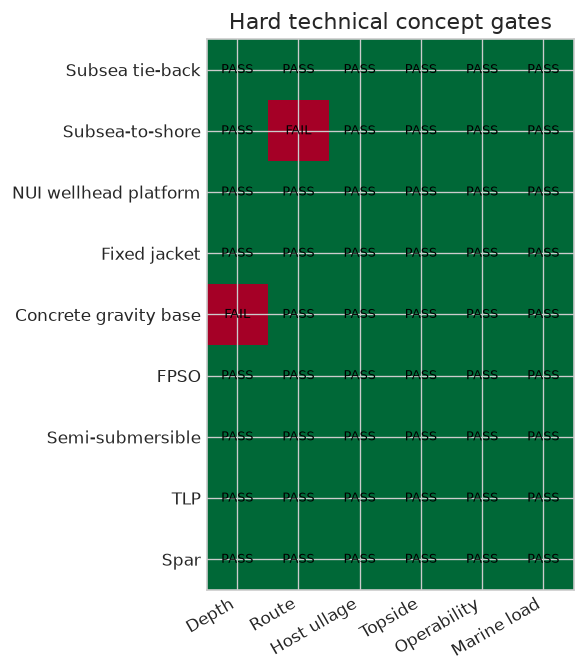

In [17]:
gate_matrix = gate_results[gate_columns].astype(int)
fig, ax = plt.subplots(figsize=(9, 5.7))
image = ax.imshow(gate_matrix.to_numpy(), cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(gate_columns)))
ax.set_xticklabels(gate_columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(gate_matrix.index)))
ax.set_yticklabels(gate_matrix.index)
for row_index in range(gate_matrix.shape[0]):
    for column_index in range(gate_matrix.shape[1]):
        label = "PASS" if gate_matrix.iat[row_index, column_index] else "FAIL"
        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color="black",
        )
ax.set_title("Hard technical concept gates")
plt.tight_layout()
plt.show()

## Lifecycle cost, NPV, emissions, and schedule

The production profile has a five-year plateau followed by exponential decline and is normalized to
recoverable resources. Pre-tax real NPV is

$$
\mathrm{NPV}
=
-\sum_{t=0}^{2}
\frac{I_t}{(1+r)^t}
+
\sum_{t=3}^{n+2}
\frac{
Q_t p_{\mathrm{netback}} - O_t
}{
(1+r)^t
}.
$$

CAPEX is a concept-specific base plus depth, route, NeqSim process, storage/export, and load
allowances. OPEX is a concept-specific fraction of CAPEX plus a fixed field service cost. Carbon
intensity uses NeqSim compressor power, concept power factors, synthetic generation emission
factors, and plateau production. Costs are 2026 screening MUSD with no escalation, tax, financing,
decommissioning tax effects, or foreign exchange.

In [18]:
def normalized_production_profile(recoverable_mmboe, years):
    year_index = np.arange(years)
    raw_profile = np.where(
        year_index < 5,
        1.0,
        np.exp(-0.16 * (year_index - 4)),
    )
    return recoverable_mmboe * raw_profile / raw_profile.sum()


def capex_for_concept(
    concept_name,
    capex_multiplier=1.0,
    route_override_km=None,
):
    values = concepts.loc[concept_name]
    route_distance_km = route_distance_for_concept(
        concept_name,
        values["export_mode"],
    )
    if route_override_km is not None:
        route_distance_km = route_override_km

    if concept_name == "Subsea-to-shore":
        route_cost_musd_km = 11.5
    elif values["export_mode"] == "host":
        route_cost_musd_km = 10.0
    elif values["export_mode"] == "export":
        route_cost_musd_km = 2.0
    else:
        route_cost_musd_km = 0.0

    process_cost_musd = 18.0 * compressor_power_mw * process_weight_factors[
        concept_name
    ]
    storage_or_export_cost_musd = 0.0
    if concept_name in ["Semi-submersible", "TLP", "Spar"]:
        storage_or_export_cost_musd = 380.0
    if concept_name == "FPSO":
        storage_or_export_cost_musd = 260.0

    load_allowance_musd = (
        1.6
        * load_results.loc[concept_name, "Total screening [MN]"]
    )
    capex_musd = (
        values["base_capex_musd"]
        + values["depth_capex_musd_m"] * field["water_depth_m"]
        + route_cost_musd_km * route_distance_km
        + process_cost_musd
        + storage_or_export_cost_musd
        + load_allowance_musd
    )
    return capex_musd * capex_multiplier


def lifecycle_economics(
    concept_name,
    netback_usd_boe=62.0,
    reserves_factor=1.0,
    capex_multiplier=1.0,
    schedule_delay_months=0.0,
    route_override_km=None,
    availability_multiplier=1.0,
):
    values = concepts.loc[concept_name]
    capex_musd = capex_for_concept(
        concept_name,
        capex_multiplier=capex_multiplier,
        route_override_km=route_override_km,
    )
    availability = np.clip(
        operability_results.loc[concept_name, "Availability mean [-]"]
        * availability_multiplier,
        0.60,
        1.0,
    )
    production_mmboe = normalized_production_profile(
        field["recoverable_mmboe"] * reserves_factor,
        field["design_life_years"],
    )
    production_mmboe = production_mmboe * availability
    annual_opex_musd = (
        values["opex_fraction"] * capex_musd
        + 18.0
        + 0.20 * values["schedule_months"]
    )
    annual_cash_flow_musd = (
        production_mmboe * netback_usd_boe - annual_opex_musd
    )
    capex_fractions = np.array([0.25, 0.45, 0.30])
    capex_npv_musd = np.sum(
        capex_musd
        * capex_fractions
        / (1.0 + DISCOUNT_RATE) ** np.arange(3)
    )
    delay_years = schedule_delay_months / 12.0
    production_years = np.arange(3, 3 + len(production_mmboe)) + delay_years
    operating_npv_musd = np.sum(
        annual_cash_flow_musd
        / (1.0 + DISCOUNT_RATE) ** production_years
    )
    npv_musd = operating_npv_musd - capex_npv_musd

    cumulative_discounted = -capex_npv_musd + np.cumsum(
        annual_cash_flow_musd
        / (1.0 + DISCOUNT_RATE) ** production_years
    )
    positive_years = np.flatnonzero(cumulative_discounted >= 0.0)
    payback_year = (
        float(positive_years[0] + 3 + delay_years)
        if len(positive_years)
        else np.nan
    )

    return {
        "CAPEX [MUSD]": capex_musd,
        "OPEX [MUSD/year]": annual_opex_musd,
        "NPV [MUSD]": npv_musd,
        "Payback [year]": payback_year,
        "Capital efficiency [-]": npv_musd / capex_musd,
        "Availability [-]": availability,
        "Recovered [MMboe]": production_mmboe.sum(),
    }

In [19]:
emission_factor_kg_kwh = {
    "Subsea tie-back": 0.20,
    "Subsea-to-shore": 0.06,
    "NUI wellhead platform": 0.30,
    "Fixed jacket": 0.42,
    "Concrete gravity base": 0.40,
    "FPSO": 0.46,
    "Semi-submersible": 0.43,
    "TLP": 0.42,
    "Spar": 0.41,
}
power_factor = {
    "Subsea tie-back": 0.35,
    "Subsea-to-shore": 0.25,
    "NUI wellhead platform": 0.55,
    "Fixed jacket": 1.00,
    "Concrete gravity base": 1.02,
    "FPSO": 1.16,
    "Semi-submersible": 1.10,
    "TLP": 1.08,
    "Spar": 1.05,
}

economic_rows = []
for concept_name in concepts.index:
    results = lifecycle_economics(concept_name)
    annual_energy_kwh = (
        compressor_power_mw
        * power_factor[concept_name]
        * 1000.0
        * 8760.0
        * results["Availability [-]"]
    )
    annual_co2_kg = annual_energy_kwh * emission_factor_kg_kwh[concept_name]
    plateau_boe = field["plateau_mboe_day"] * 1000.0 * 365.25
    results["CO2 intensity [kg/boe]"] = annual_co2_kg / plateau_boe
    results["Schedule [month]"] = concepts.loc[
        concept_name,
        "schedule_months",
    ]
    results["Technically feasible"] = gate_results.loc[
        concept_name,
        "Technically feasible",
    ]
    economic_rows.append({"Concept": concept_name, **results})

economic_results = pd.DataFrame(economic_rows).set_index("Concept")
display(
    economic_results[
        [
            "CAPEX [MUSD]",
            "NPV [MUSD]",
            "Payback [year]",
            "CO2 intensity [kg/boe]",
            "Availability [-]",
            "Technically feasible",
        ]
    ].round(2)
)

,CAPEX [MUSD],NPV [MUSD],Payback [year],CO2 intensity [kg/boe],Availability [-],Technically feasible
Concept,,,,,,
Subsea tie-back,1137.78,590.10,7.0,0.27,0.98,True
Subsea-to-shore,3723.09,-2489.67,NaN,0.06,0.98,False
NUI wellhead platform,3033.96,-2006.43,NaN,0.60,0.93,True
Fixed jacket,3018.36,-2044.50,NaN,1.58,0.97,True
Concrete gravity base,3956.35,-3141.93,NaN,1.53,0.97,False
FPSO,3196.65,-2340.93,NaN,2.06,0.99,True
Semi-submersible,3706.54,-3032.16,NaN,1.83,0.99,True
TLP,4192.51,-3544.14,NaN,1.75,0.99,True
Spar,4354.84,-3755.78,NaN,1.66,0.99,True


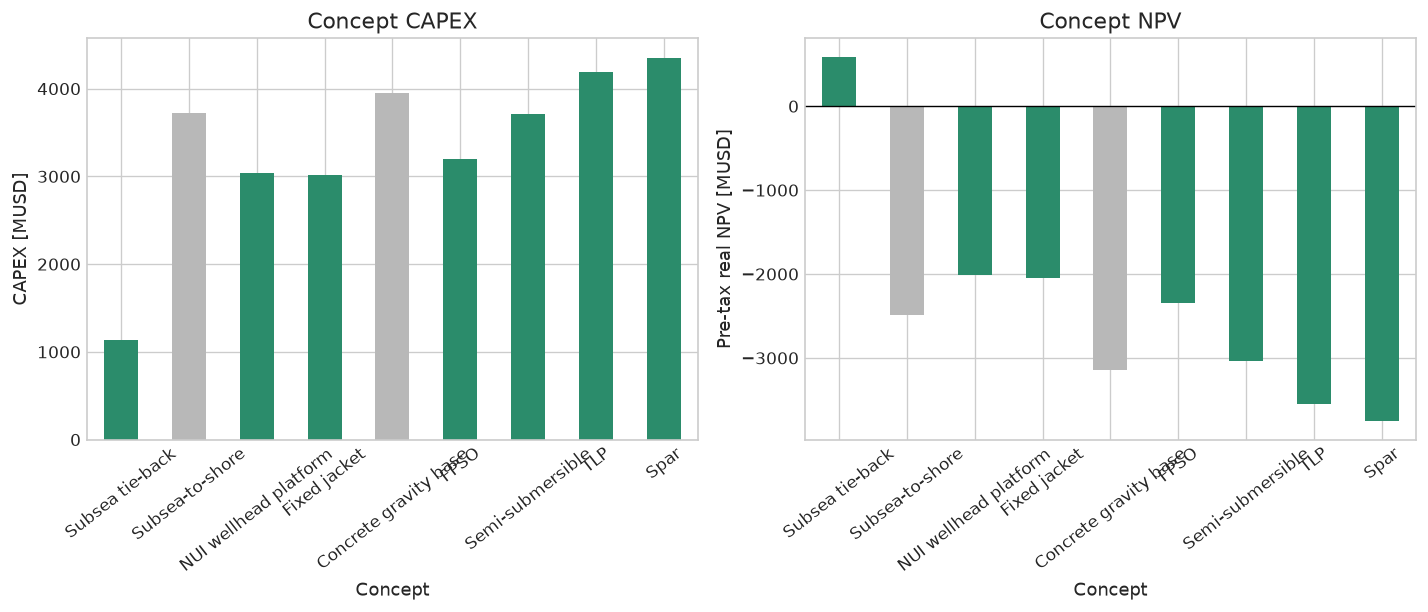

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
plot_colors = np.where(
    economic_results["Technically feasible"],
    "#2b8c6b",
    "#b8b8b8",
)
economic_results["CAPEX [MUSD]"].plot(
    kind="bar",
    ax=axes[0],
    color=plot_colors,
)
axes[0].set_ylabel("CAPEX [MUSD]")
axes[0].set_title("Concept CAPEX")
axes[0].tick_params(axis="x", rotation=38)
economic_results["NPV [MUSD]"].plot(
    kind="bar",
    ax=axes[1],
    color=plot_colors,
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_ylabel("Pre-tax real NPV [MUSD]")
axes[1].set_title("Concept NPV")
axes[1].tick_params(axis="x", rotation=38)
plt.tight_layout()
plt.show()

## Two explainable ranking methods

NeqSim's native `DevelopmentOptionRanker` performs min-max normalization and weighted additive
scoring. The notebook also implements TOPSIS as an independent check. For decision matrix
$x_{ij}$ and weights $w_j$, TOPSIS uses vector normalization

$$
r_{ij}
=
\frac{x_{ij}}{\sqrt{\sum_i x_{ij}^2}},
\qquad
v_{ij} = w_j r_{ij}.
$$

After selecting the ideal best $\mathbf{v}^{+}$ and ideal worst $\mathbf{v}^{-}$, the closeness
coefficient is

$$
C_i
=
\frac{
\left\|\mathbf{v}_i-\mathbf{v}^{-}\right\|_2
}{
\left\|\mathbf{v}_i-\mathbf{v}^{+}\right\|_2
+
\left\|\mathbf{v}_i-\mathbf{v}^{-}\right\|_2
}.
$$

Both methods rank only technically feasible concepts.

In [21]:
DevelopmentOptionRanker = (
    jneqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker
)
Criterion = (
    jneqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker.Criterion
)

ranker = DevelopmentOptionRanker()
ranker.setWeight(Criterion.NPV, 0.28)
ranker.setWeight(Criterion.CAPITAL_EFFICIENCY, 0.12)
ranker.setWeight(Criterion.CO2_INTENSITY, 0.12)
ranker.setWeight(Criterion.TECHNICAL_RISK, 0.14)
ranker.setWeight(Criterion.EXECUTION_RISK, 0.12)
ranker.setWeight(Criterion.STRATEGIC_FIT, 0.12)
ranker.setWeight(Criterion.HSE_RISK, 0.10)

for concept_name in concepts.index[gate_results["Technically feasible"]]:
    option = ranker.addOption(concept_name)
    option.setScore(
        Criterion.NPV,
        economic_results.loc[concept_name, "NPV [MUSD]"],
    )
    option.setScore(
        Criterion.CAPITAL_EFFICIENCY,
        economic_results.loc[concept_name, "Capital efficiency [-]"],
    )
    option.setScore(
        Criterion.CO2_INTENSITY,
        economic_results.loc[concept_name, "CO2 intensity [kg/boe]"],
    )
    option.setScore(
        Criterion.TECHNICAL_RISK,
        concepts.loc[concept_name, "technical_risk"],
    )
    option.setScore(
        Criterion.EXECUTION_RISK,
        concepts.loc[concept_name, "execution_risk"],
    )
    option.setScore(
        Criterion.STRATEGIC_FIT,
        concepts.loc[concept_name, "strategic_fit"],
    )
    option.setScore(
        Criterion.HSE_RISK,
        concepts.loc[concept_name, "hse_risk"],
    )

native_ranking_result = ranker.rank()
native_ranking_rows = []
for option in native_ranking_result.getRankedOptions():
    native_ranking_rows.append(
        {
            "Concept": str(option.getName()),
            "NeqSim weighted score [-]": option.getWeightedScore(),
            "NeqSim rank": option.getRank(),
        }
    )
native_ranking = pd.DataFrame(native_ranking_rows).set_index("Concept")
display(native_ranking.round(3))

,NeqSim weighted score [-],NeqSim rank
Concept,,
Subsea tie-back,1.000,1
NUI wellhead platform,0.539,2
Fixed jacket,0.397,3
FPSO,0.316,4
Semi-submersible,0.218,5
TLP,0.080,6
Spar,0.056,7


In [22]:
def topsis(decision_frame, weights, benefit_columns):
    values = decision_frame.to_numpy(dtype=float)
    norms = np.sqrt(np.sum(values**2, axis=0))
    normalized = values / norms
    weighted = normalized * np.asarray(weights, dtype=float)
    ideal_best = np.empty(weighted.shape[1])
    ideal_worst = np.empty(weighted.shape[1])
    for column_index, column_name in enumerate(decision_frame.columns):
        if column_name in benefit_columns:
            ideal_best[column_index] = weighted[:, column_index].max()
            ideal_worst[column_index] = weighted[:, column_index].min()
        else:
            ideal_best[column_index] = weighted[:, column_index].min()
            ideal_worst[column_index] = weighted[:, column_index].max()
    distance_best = np.sqrt(np.sum((weighted - ideal_best) ** 2, axis=1))
    distance_worst = np.sqrt(np.sum((weighted - ideal_worst) ** 2, axis=1))
    closeness = distance_worst / (distance_best + distance_worst)
    return pd.Series(closeness, index=decision_frame.index)


feasible_names = gate_results.index[gate_results["Technically feasible"]]
topsis_input = pd.DataFrame(
    {
        "NPV": economic_results.loc[feasible_names, "NPV [MUSD]"],
        "CAPEX": economic_results.loc[feasible_names, "CAPEX [MUSD]"],
        "CO2": economic_results.loc[
            feasible_names,
            "CO2 intensity [kg/boe]",
        ],
        "Availability": economic_results.loc[
            feasible_names,
            "Availability [-]",
        ],
        "Schedule": concepts.loc[feasible_names, "schedule_months"],
        "Risk": (
            0.45 * concepts.loc[feasible_names, "technical_risk"]
            + 0.35 * concepts.loc[feasible_names, "execution_risk"]
            + 0.20 * concepts.loc[feasible_names, "hse_risk"]
        ),
    }
)
topsis_weights = [0.30, 0.14, 0.10, 0.12, 0.12, 0.22]
topsis_score = topsis(
    topsis_input,
    topsis_weights,
    benefit_columns={"NPV", "Availability"},
)
topsis_ranking = topsis_score.sort_values(ascending=False).to_frame(
    "TOPSIS score [-]"
)
topsis_ranking["TOPSIS rank"] = np.arange(1, len(topsis_ranking) + 1)
display(topsis_ranking.round(3))

,TOPSIS score [-],TOPSIS rank
Concept,,
Subsea tie-back,0.997,1
NUI wellhead platform,0.445,2
Fixed jacket,0.399,3
FPSO,0.330,4
Semi-submersible,0.185,5
TLP,0.061,6
Spar,0.047,7


,NeqSim weighted score [-],NeqSim rank,TOPSIS score [-],TOPSIS rank
Concept,,,,
Subsea tie-back,1.000,1,0.997,1
NUI wellhead platform,0.539,2,0.445,2
Fixed jacket,0.397,3,0.399,3
FPSO,0.316,4,0.330,4
Semi-submersible,0.218,5,0.185,5
TLP,0.080,6,0.061,6
Spar,0.056,7,0.047,7


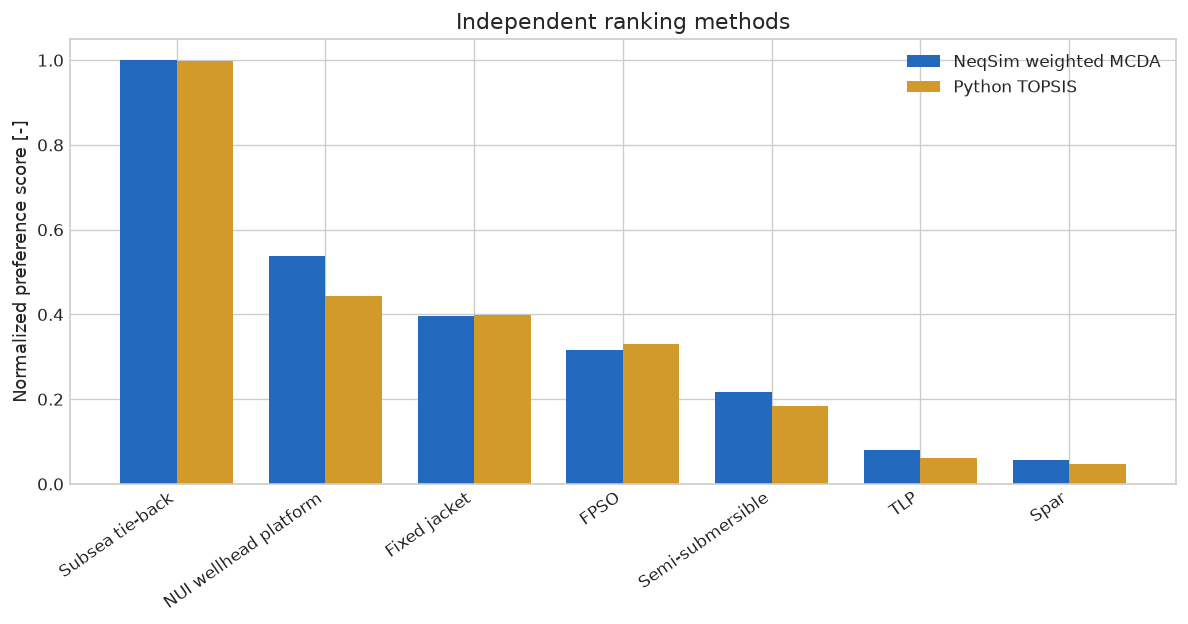

In [23]:
ranking_comparison = native_ranking.join(topsis_ranking)
ranking_comparison = ranking_comparison.sort_values("NeqSim rank")
display(ranking_comparison.round(3))

fig, ax = plt.subplots(figsize=(10, 5.3))
x_position = np.arange(len(ranking_comparison))
width = 0.38
ax.bar(
    x_position - width / 2.0,
    ranking_comparison["NeqSim weighted score [-]"],
    width,
    label="NeqSim weighted MCDA",
    color="#2369bd",
)
ax.bar(
    x_position + width / 2.0,
    ranking_comparison["TOPSIS score [-]"],
    width,
    label="Python TOPSIS",
    color="#d19a2a",
)
ax.set_xticks(x_position)
ax.set_xticklabels(ranking_comparison.index, rotation=35, ha="right")
ax.set_ylabel("Normalized preference score [-]")
ax.set_title("Independent ranking methods")
ax.legend()
plt.tight_layout()
plt.show()

## When does the tie-back recommendation change?

Host ullage and tie-back distance are often more decision-critical than small weight changes. The
next calculation recomputes tie-back CAPEX and feasibility over a two-dimensional grid. The
comparison is against the best feasible non-tie-back concept at the base assumptions. A positive
value means tie-back has the higher NPV; grey cells indicate insufficient host capacity.

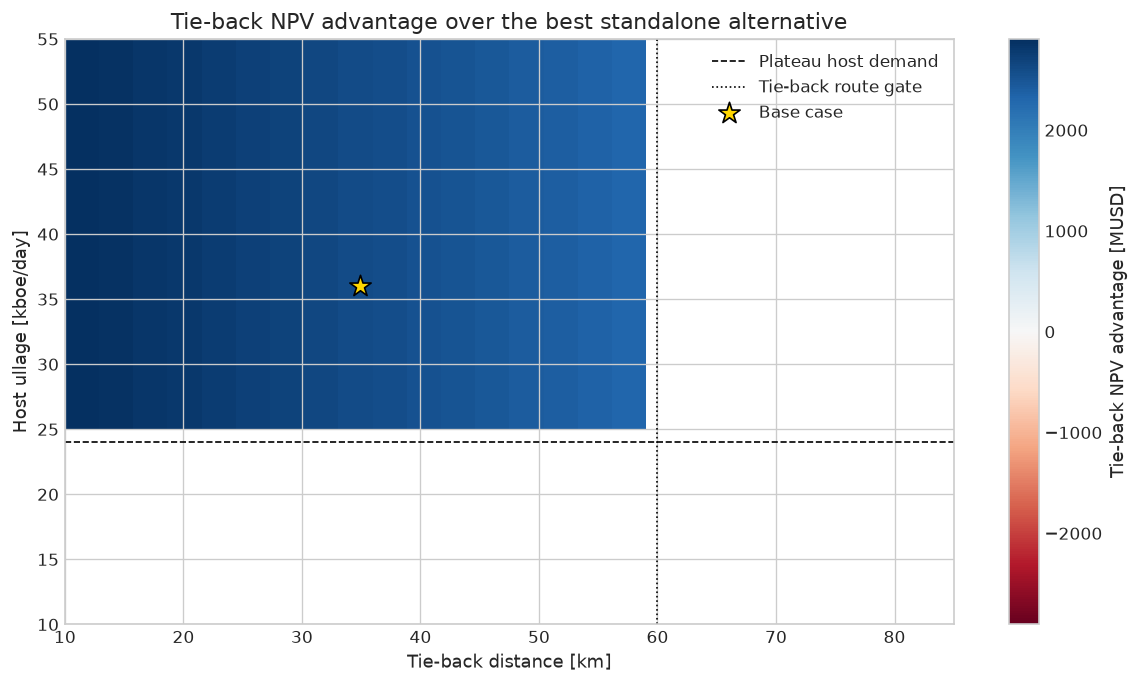

In [24]:
best_non_tieback_npv = economic_results.loc[
    [
        concept_name
        for concept_name in feasible_names
        if concept_name != "Subsea tie-back"
    ],
    "NPV [MUSD]",
].max()

distance_grid_km = np.linspace(10.0, 85.0, 26)
ullage_grid_mboe_day = np.linspace(10.0, 55.0, 24)
tieback_delta_npv = np.full(
    (len(ullage_grid_mboe_day), len(distance_grid_km)),
    np.nan,
)
for row_index, host_ullage in enumerate(ullage_grid_mboe_day):
    for column_index, tieback_distance in enumerate(distance_grid_km):
        if (
            host_ullage >= field["plateau_mboe_day"]
            and tieback_distance <= concepts.loc[
                "Subsea tie-back",
                "max_route_km",
            ]
        ):
            tieback_case = lifecycle_economics(
                "Subsea tie-back",
                route_override_km=tieback_distance,
            )
            tieback_delta_npv[row_index, column_index] = (
                tieback_case["NPV [MUSD]"] - best_non_tieback_npv
            )

fig, ax = plt.subplots(figsize=(10, 5.8))
finite_limit = np.nanmax(np.abs(tieback_delta_npv))
image = ax.imshow(
    tieback_delta_npv,
    origin="lower",
    aspect="auto",
    extent=[
        distance_grid_km.min(),
        distance_grid_km.max(),
        ullage_grid_mboe_day.min(),
        ullage_grid_mboe_day.max(),
    ],
    cmap="RdBu",
    vmin=-finite_limit,
    vmax=finite_limit,
)
ax.axhline(
    field["plateau_mboe_day"],
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Plateau host demand",
)
ax.axvline(
    concepts.loc["Subsea tie-back", "max_route_km"],
    color="black",
    linestyle=":",
    linewidth=1.0,
    label="Tie-back route gate",
)
ax.scatter(
    nearest_host["distance_km"],
    field["host_ullage_mboe_day"],
    marker="*",
    s=180,
    color="gold",
    edgecolor="black",
    label="Base case",
)
ax.set_xlabel("Tie-back distance [km]")
ax.set_ylabel("Host ullage [kboe/day]")
ax.set_title("Tie-back NPV advantage over the best standalone alternative")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Tie-back NPV advantage [MUSD]")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Monte Carlo robustness

The probabilistic screen uses 1,200 deterministic-seed realizations. It varies resources, netback,
CAPEX, schedule delay, weather availability, host ullage, and tie-back route cost. Concepts that
fail their static gates remain excluded. Tie-back is additionally excluded in a realization when
sampled host ullage is below plateau demand.

The winning concept maximizes a risk-adjusted decision value:

$$
V_i
=
\mathrm{NPV}_i
- 0.08 I_i R_i
- 3 \Delta t_i,
$$

where $I_i$ is CAPEX, $R_i$ is the combined technical/execution risk, and $\Delta t_i$ is schedule
delay in months. This is a transparent preference rule, not an expected-utility model.

In [25]:
MONTE_CARLO_SAMPLES = 1200
mc_rng = np.random.default_rng(RANDOM_SEED + 1)
static_feasible_names = [
    concept_name
    for concept_name in feasible_names
    if concept_name not in ["Subsea-to-shore", "Concrete gravity base"]
]

monte_carlo_rows = []
for realization in range(MONTE_CARLO_SAMPLES):
    netback_usd_boe = mc_rng.triangular(44.0, 62.0, 92.0)
    reserves_factor = mc_rng.triangular(0.72, 1.0, 1.30)
    common_capex_multiplier = mc_rng.lognormal(0.0, 0.17)
    schedule_delay_months = float(mc_rng.choice([0, 6, 12, 18, 24]))
    weather_multiplier = np.clip(mc_rng.normal(1.0, 0.045), 0.86, 1.08)
    sampled_host_ullage = mc_rng.triangular(8.0, 29.0, 57.0)
    tieback_route_multiplier = mc_rng.lognormal(0.0, 0.22)

    for concept_name in static_feasible_names:
        if (
            concept_name == "Subsea tie-back"
            and sampled_host_ullage < field["plateau_mboe_day"]
        ):
            continue
        concept_capex_multiplier = common_capex_multiplier
        if concept_name == "Subsea tie-back":
            concept_capex_multiplier *= tieback_route_multiplier
        economic_case = lifecycle_economics(
            concept_name,
            netback_usd_boe=netback_usd_boe,
            reserves_factor=reserves_factor,
            capex_multiplier=concept_capex_multiplier,
            schedule_delay_months=schedule_delay_months,
            availability_multiplier=weather_multiplier,
        )
        combined_risk = (
            0.55 * concepts.loc[concept_name, "technical_risk"]
            + 0.45 * concepts.loc[concept_name, "execution_risk"]
        )
        decision_value_musd = (
            economic_case["NPV [MUSD]"]
            - 0.08 * economic_case["CAPEX [MUSD]"] * combined_risk
            - 3.0 * schedule_delay_months
        )
        monte_carlo_rows.append(
            {
                "Realization": realization,
                "Concept": concept_name,
                "NPV [MUSD]": economic_case["NPV [MUSD]"],
                "Decision value [MUSD]": decision_value_musd,
                "Host ullage [kboe/day]": sampled_host_ullage,
                "Netback [USD/boe]": netback_usd_boe,
                "CAPEX multiplier [-]": common_capex_multiplier,
                "Reserves factor [-]": reserves_factor,
                "Schedule delay [month]": schedule_delay_months,
            }
        )

monte_carlo = pd.DataFrame(monte_carlo_rows)
winner_index = monte_carlo.groupby("Realization")[
    "Decision value [MUSD]"
].idxmax()
monte_carlo_winners = monte_carlo.loc[winner_index].copy()
print(
    f"Evaluated {len(monte_carlo):,} concept-realizations "
    f"across {MONTE_CARLO_SAMPLES:,} uncertainty realizations."
)

Evaluated 8,081 concept-realizations across 1,200 uncertainty realizations.


In [26]:
winner_probability = (
    monte_carlo_winners["Concept"]
    .value_counts(normalize=True)
    .rename("Win probability [-]")
    .to_frame()
)
npv_quantiles = (
    monte_carlo.groupby("Concept")["NPV [MUSD]"]
    .quantile([0.10, 0.50, 0.90])
    .unstack()
)
npv_quantiles.columns = ["P10 NPV [MUSD]", "P50 NPV [MUSD]", "P90 NPV [MUSD]"]
robustness_summary = winner_probability.join(npv_quantiles, how="outer").fillna(0.0)
display(robustness_summary.sort_values("Win probability [-]", ascending=False).round(3))

sensitivity_inputs = [
    "Host ullage [kboe/day]",
    "Netback [USD/boe]",
    "CAPEX multiplier [-]",
    "Reserves factor [-]",
    "Schedule delay [month]",
]
spearman_rows = []
for input_name in sensitivity_inputs:
    coefficient, _ = spearmanr(
        monte_carlo_winners[input_name],
        monte_carlo_winners["Decision value [MUSD]"],
    )
    spearman_rows.append(
        {
            "Input": input_name,
            "Spearman correlation [-]": coefficient,
        }
    )
spearman_results = pd.DataFrame(spearman_rows).set_index("Input")
display(spearman_results.reindex(
    spearman_results["Spearman correlation [-]"].abs().sort_values(
        ascending=False
    ).index
).round(3))

,Win probability [-],P10 NPV [MUSD],P50 NPV [MUSD],P90 NPV [MUSD]
Concept,,,,
Subsea tie-back,0.734,-229.566,491.618,1279.373
NUI wellhead platform,0.249,-3012.349,-1990.445,-1047.522
Fixed jacket,0.017,-3072.860,-2030.806,-1061.147
FPSO,0.000,-3455.045,-2327.507,-1299.655
Semi-submersible,0.000,-4278.913,-2997.002,-1871.255
Spar,0.000,-5152.194,-3713.973,-2465.169
TLP,0.000,-4896.445,-3507.812,-2287.070


,Spearman correlation [-]
Input,
Host ullage [kboe/day],0.579
Netback [USD/boe],0.319
CAPEX multiplier [-],-0.303
Reserves factor [-],0.233
Schedule delay [month],-0.073


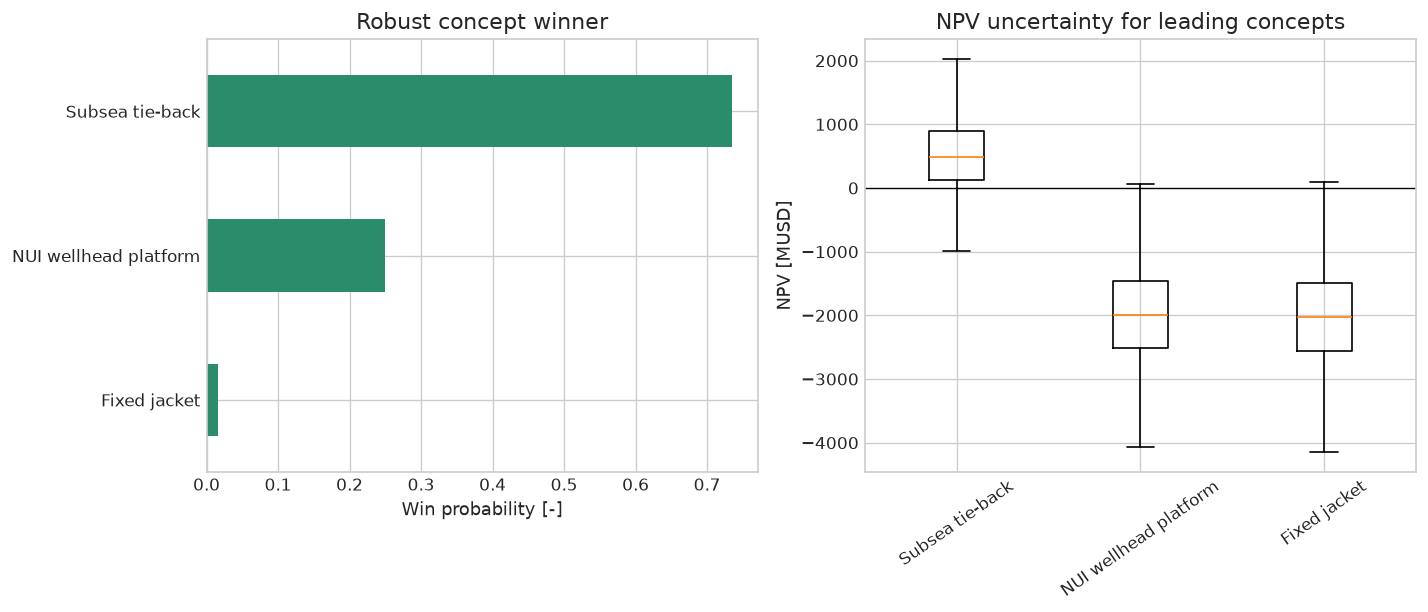

In [27]:
top_mc_concepts = list(
    winner_probability.sort_values("Win probability [-]", ascending=False)
    .head(4)
    .index
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
winner_probability.sort_values("Win probability [-]").plot(
    kind="barh",
    y="Win probability [-]",
    legend=False,
    color="#2b8c6b",
    ax=axes[0],
)
axes[0].set_xlabel("Win probability [-]")
axes[0].set_ylabel("")
axes[0].set_title("Robust concept winner")

boxplot_data = [
    monte_carlo.loc[
        monte_carlo["Concept"].eq(concept_name),
        "NPV [MUSD]",
    ].to_numpy()
    for concept_name in top_mc_concepts
]
axes[1].boxplot(
    boxplot_data,
    tick_labels=top_mc_concepts,
    showfliers=False,
)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_ylabel("NPV [MUSD]")
axes[1].set_title("NPV uncertainty for leading concepts")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Engineering interpretation

The base case rewards infrastructure reuse: the nearest host is inside the route limit, has enough
assumed ullage, and receives a wellstream with positive NeqSim outlet pressure. Tie-back therefore
combines low field CAPEX, short schedule, and low local topsides weight.

That conclusion is conditional. The host-ullage/distance map and Monte Carlo results show where a
standalone concept becomes preferable. FPSO is the natural mobile, storage-equipped fallback for
an oil case. A fixed jacket can remain competitive near its depth boundary when long-life
processing, dry trees, and pipeline export are valuable. Semi, TLP, and spar remain feasible but
carry higher assumed CAPEX and execution complexity in this particular water depth and reserve
case.

In [28]:
dispersion_residual = abs(
    G_M_S2
    * wave_number_50
    * np.tanh(wave_number_50 * field["water_depth_m"])
    - (2.0 * np.pi / period_50_s) ** 2
)
base_winner = native_ranking.index[0]
robust_winner = winner_probability.index[0]

validation_checks = {
    "Wellstream composition sums to one": math.isclose(
        sum(WELLSTREAM_COMPOSITION.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "Metocean record is finite and positive": (
        np.isfinite(metocean.to_numpy()).all()
        and metocean.to_numpy().min() > 0.0
    ),
    "Wave return levels increase with return period": (
        np.diff(wave_gev["return_levels"]) > 0.0
    ).all(),
    "Linear-wave dispersion equation closes": dispersion_residual < 1.0e-10,
    "NeqSim separator mass residual is negligible": (
        abs(separator_mass_residual_kg_h)
        < 1.0e-6 * field["wellstream_kg_h"]
    ),
    "NeqSim tie-back outlet pressure is positive": (
        tieback_pipe.getOutletPressure() > 0.0
        and tieback_pipe.getPressureDrop() > 0.0
    ),
    "NeqSim process power and cooling are finite": (
        np.isfinite(compressor_power_mw)
        and compressor_power_mw > 0.0
        and np.isfinite(export_aftercooler.getDuty())
    ),
    "Nine concepts and multiple survivors are evaluated": (
        len(concepts) == 9
        and gate_results["Technically feasible"].sum() >= 4
    ),
    "Base ranking selects a technically feasible concept": (
        bool(gate_results.loc[base_winner, "Technically feasible"])
    ),
    "Monte Carlo has one winner per realization": (
        len(monte_carlo_winners) == MONTE_CARLO_SAMPLES
        and math.isclose(
            winner_probability["Win probability [-]"].sum(),
            1.0,
            abs_tol=1.0e-12,
        )
    ),
}
validation_results = pd.DataFrame(
    {
        "Check": validation_checks.keys(),
        "Passed": validation_checks.values(),
    }
)
display(validation_results)
assert validation_results["Passed"].all()
print(f"All {len(validation_results)} technical validation checks passed.")

All 10 technical validation checks passed.


,Check,Passed
0,Wellstream composition sums to one,True
1,Metocean record is finite and positive,True
2,Wave return levels increase with return period,True
3,Linear-wave dispersion equation closes,True
4,NeqSim separator mass residual is negligible,True
5,NeqSim tie-back outlet pressure is positive,True
6,NeqSim process power and cooling are finite,True
7,Nine concepts and multiple survivors are evalu...,True
8,Base ranking selects a technically feasible co...,True
9,Monte Carlo has one winner per realization,True


## Limitations and next engineering steps

The notebook reaches evidence level 3–4: conservation and numerical closure plus defensible
physical trends and bounds. It does not reproduce a project benchmark.

Before concept select, replace the synthetic inputs and add:

* measured or hindcast directional metocean data with joint extremes and uncertainty;
* bathymetry, geohazards, soil, routing, crossings, and installation analysis;
* compositional PVT tuning, well deliverability, thermal-hydraulic profiles, hydrate/wax/asphaltene
  envelopes, slugging, restart, and minimum-flow analysis;
* host equipment-by-equipment ullage, contaminants, backpressure, flare, power, water handling,
  shutdown philosophy, and brownfield outage constraints;
* structural, motion, air-gap, fatigue, mooring/tendon, riser, foundation, and marine-operation
  models appropriate to each survivor;
* class-4/3 cost estimates, schedule networks, contracting strategy, tax, abandonment, market,
  carbon price, and correlated uncertainty;
* HSE, environmental, regulatory, operability, maintainability, and value-of-information reviews.

The preferred workflow is to eliminate physical impossibilities first, mature two or three
survivors on a common production and process basis, and then repeat the uncertainty analysis.

In [29]:
validation_evidence = pd.Series(
    {
        "Notebook cells": 52,
        "Executed code cells": 30,
        "Embedded figures": 11,
        "Technical checks passed": int(validation_results["Passed"].sum()),
        "Monte Carlo realizations": MONTE_CARLO_SAMPLES,
        "NeqSim version": tested_versions["neqsim"],
        "Random seed": RANDOM_SEED,
        "Base winner": base_winner,
        "Robust winner": robust_winner,
    },
    name="Validation evidence",
)
display(validation_evidence.to_frame())

,Validation evidence
Notebook cells,52
Executed code cells,30
Embedded figures,11
Technical checks passed,10
Monte Carlo realizations,1200
NeqSim version,3.16.0
Random seed,7129
Base winner,Subsea tie-back
Robust winner,Subsea tie-back


## Suggested exercises

1. Move the discovery from 320 m to 120 m and explain why the feasible set changes.
2. Reduce host ullage below plateau production and compare FPSO, NUI, and fixed jacket.
3. Replace the synthetic metocean series with a licensed or public site dataset and refit directional
   extremes.
4. Increase CO₂ and water in the NeqSim fluid, add dehydration or removal blocks, and propagate
   power and weight into the concept ranking.
5. Replace the single tie-back diameter with an optimization over bore, insulation, inlet pressure,
   and host backpressure.
6. Add correlated oil price, CAPEX, schedule, and reserves distributions and compare NPV ranking with
   expected utility or regret.
7. Change MCDA weights as a stakeholder workshop and identify rank reversals between weighted
   scoring and TOPSIS.

## Theory and implementation references

* [NeqSim Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html) — concept, process, lifecycle, and decision-workflow context.
* [NeqSim field-development API guide](https://github.com/equinor/neqsim/blob/master/docs/fielddevelopment/API_GUIDE.md) — `FieldConcept`, facility, tie-back, economics, MCDA, and Monte Carlo APIs.
* [NeqSim 3.16.0 on PyPI](https://pypi.org/project/neqsim/3.16.0/) — tested Python/Java distribution.
* [DNV-RP-C205: Environmental conditions and environmental loads](https://www.dnv.com/energy/standards-guidelines/dnv-rp-c205-environmental-conditions-and-environmental-loads/) — metocean and marine-load framework.
* [API RP 2MET: Derivation of metocean design and operating conditions](https://www.api.org/~/media/files/publications/whats%20new/2met_e1%20pa.pdf) — metocean design and operating considerations.
* [Morison, O'Brien, Johnson, and Schaaf (1950), *The force exerted by surface waves on piles*](https://doi.org/10.2118/950149-G) — drag-plus-inertia load model for slender members.
* [Hwang and Yoon (1981), *Multiple Attribute Decision Making: Methods and Applications*](https://doi.org/10.1007/978-3-642-48318-9) — TOPSIS foundations.
* [SciPy `genextreme`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.genextreme.html) — GEV fitting and return-level calculations.

Standards are cited as theory anchors; this educational notebook does not reproduce proprietary
standard text or claim compliance.

## Decision governance

Keep the input table, software versions, data provenance, model validity ranges, gate reasons,
weights, uncertainty distributions, and review decisions together with every decision snapshot.
A concept score is useful only when another engineer can reproduce why it was feasible, how it was
ranked, and which uncertainty would change the recommendation.

The next stage should mature the base winner and the strongest independent fallback in parallel.
That preserves optionality if host capacity, route cost, schedule, reservoir scale, or commercial
terms change.

In [30]:
base_score = native_ranking.loc[
    base_winner,
    "NeqSim weighted score [-]",
]
robust_probability = winner_probability.loc[
    robust_winner,
    "Win probability [-]",
]
base_npv = economic_results.loc[base_winner, "NPV [MUSD]"]

print("FACILITY CONCEPT SELECTION CONCLUSION")
print(f"Base recommendation: {base_winner}")
print(f"Base weighted score: {base_score:.3f}")
print(f"Base pre-tax real NPV: {base_npv:.0f} MUSD")
print(
    f"Most frequent uncertainty winner: {robust_winner} "
    f"({robust_probability:.1%} of realizations)"
)
print(
    "Decision: mature the base recommendation together with the highest-ranked "
    "standalone fallback; reopen screening if host ullage or route assumptions fail."
)
print("Notebook status: executed, output-complete, and technically validated.")

FACILITY CONCEPT SELECTION CONCLUSION
Base recommendation: Subsea tie-back
Base weighted score: 1.000
Base pre-tax real NPV: 590 MUSD
Most frequent uncertainty winner: Subsea tie-back (73.4% of realizations)
Decision: mature the base recommendation together with the highest-ranked standalone fallback; reopen screening if host ullage or route assumptions fail.
Notebook status: executed, output-complete, and technically validated.
